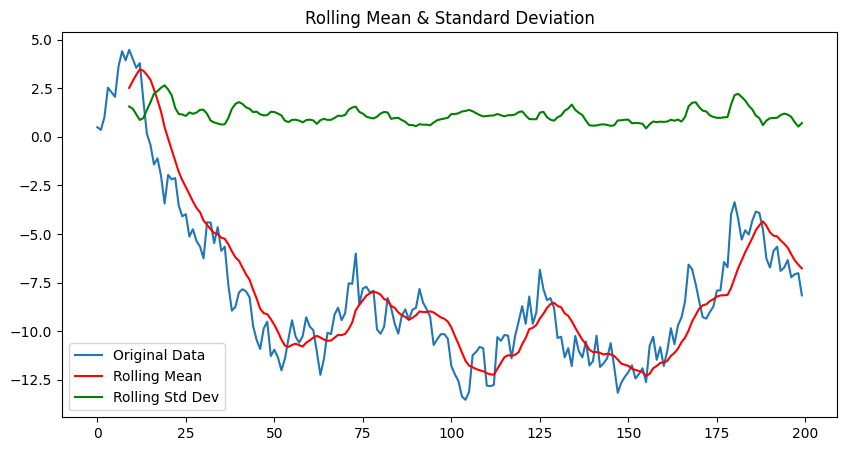

Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -2.3073
p-value: 0.1696
Critical Values: {'1%': -3.4636447617687436, '5%': -2.8761761179270766, '10%': -2.57457158581854}
Conclusion: The time series is Non-Stationary.

Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 0.7001
p-value: 0.0135
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: The time series is Non-Stationary.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

def generate_time_series(n=100, seed=42):
    np.random.seed(seed)
    return np.cumsum(np.random.randn(n))

def adf_test(series):
    result = adfuller(series)
    print("Augmented Dickey-Fuller (ADF) Test:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:", result[4])
    if result[1] < 0.05:
        print("Conclusion: The time series is Stationary.\n")
    else:
        print("Conclusion: The time series is Non-Stationary.\n")

def kpss_test(series):
    result = kpss(series, regression='c', nlags='auto')
    print("Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:")
    print(f"KPSS Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:", result[3])
    if result[1] < 0.05:
        print("Conclusion: The time series is Non-Stationary.\n")
    else:
        print("Conclusion: The time series is Stationary.\n")

def plot_rolling_statistics(series, window=10):
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()

    plt.figure(figsize=(10,5))
    plt.plot(series, label="Original Data")
    plt.plot(rolling_mean, label="Rolling Mean", color='red')
    plt.plot(rolling_std, label="Rolling Std Dev", color='green')
    plt.legend()
    plt.title("Rolling Mean & Standard Deviation")
    plt.show()

if __name__ == "__main__":
    data = generate_time_series(200)
    df = pd.Series(data)

    plot_rolling_statistics(df)
    adf_test(df)
    kpss_test(df)


Mean Squared Error: 5.6644923683177115


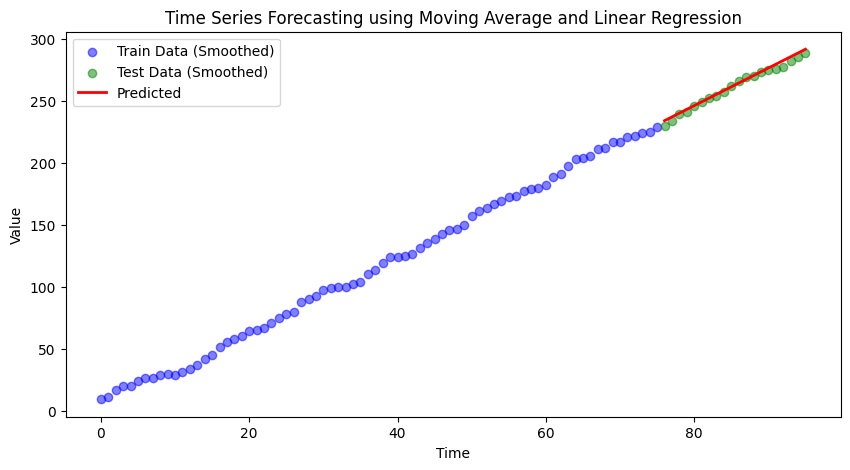

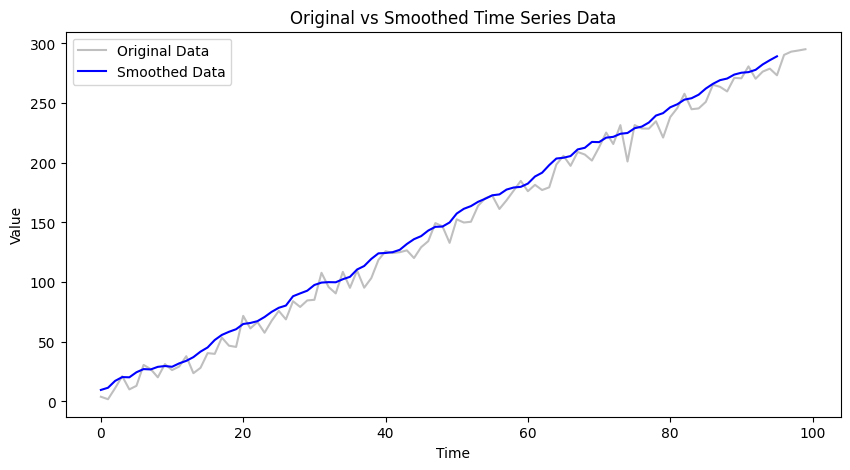

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Function to generate synthetic time series data
def generate_data(n_samples=100):
    np.random.seed(42)
    X = np.arange(n_samples).reshape(-1, 1)  # Time steps as feature
    y = 3 * X.flatten() + np.random.normal(scale=8, size=n_samples)  # Linear trend with noise
    return X, y

# Function to apply moving average smoothing
def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Load generated data
X, y = generate_data()

# Apply moving average smoothing
y_smoothed = moving_average(y, window_size=5)
X_smoothed = X[:len(y_smoothed)]  # Adjust X to match smoothed y

# Split the dataset into training and testing sets
split_ratio = 0.8
split_index = int(len(X_smoothed) * split_ratio)
X_train, X_test = X_smoothed[:split_index], X_smoothed[split_index:]
y_train, y_test = y_smoothed[:split_index], y_smoothed[split_index:]

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute model performance
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot the results
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, label='Train Data (Smoothed)', color='blue', alpha=0.5)
plt.scatter(X_test, y_test, label='Test Data (Smoothed)', color='green', alpha=0.5)
plt.plot(X_test, y_pred, label='Predicted', color='red', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Time Series Forecasting using Moving Average and Linear Regression')
plt.show()

# Plot original vs smoothed data
plt.figure(figsize=(10, 5))
plt.plot(X, y, label='Original Data', color='gray', alpha=0.5)
plt.plot(X_smoothed, y_smoothed, label='Smoothed Data', color='blue')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Original vs Smoothed Time Series Data')
plt.show()
